In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
restaurants = pd.read_parquet('restaurants.parquet')

In [3]:
listings = pd.read_parquet('listings.parquet')
restaurants_cuisines = pd.read_parquet('restaurants_cuisines.parquet')

In [4]:
print(f"{len(restaurants)} restaurants | {len(listings)} listings | {len(restaurants_cuisines)} cuisine-links")

12499 restaurants | 20915 listings | 29363 cuisine-links


# Hypothesis 1: Engagement Concentration

## 1. Sample: Zomato's Bangalore engagement (votes) is severely concentrated among a small fraction of restaurants, leaving a large "invisible" long tail.

## 2. Operationalization: Gini Coefficients of restaurants['votes'], zeroes included.

## 3. Pre-registered threshold: Gini >= 0.60, counts as severe concentration (higher than most national income-inequality figures, a deliberately demanding bar). 

## 4. Frame: restaurants (restaurant grain), not listings. Concentration must be measured per unique restaurant or popular places get counted multiple times.

In [5]:
def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    cum = np.cumsum(x)
    return (2 * np.sum(np.arange(1, n+1) * x) / (n * cum[-1])) - (n + 1) / n

### Prediction of Gini Score - 0.73

In [6]:
votes = restaurants['votes'].values
g = gini(votes)
s = np.sort(votes)[::-1]
top10 = s[:int(0.1*len(s))].sum() / s.sum()
print(f"Gini: {g:.3f} | Top 10% hold {top10:.1%} of votes")

Gini: 0.823 | Top 10% hold 71.3% of votes


### Actual Gini Score - 0.823 is greater than the predicted Gini Score - 0.730

### Predicted Gini Score was based on the mean and the median of the votes distribution but the extra 0.09 seems to have been contributed by two main factors :
### i. Zero-vote floors where multiple restaurants have 0 votes listed.
### ii. 16,832 vote-ceiling that seems to be pulling the votes upward.

### Both Gini - 0.823 and Top 10% holds 71% are independant lenses at the same concentration. 
### This means that a single decile holds 71% (three-quarters) of the entire votes which is was a Gini Score of 0.823 looks like.

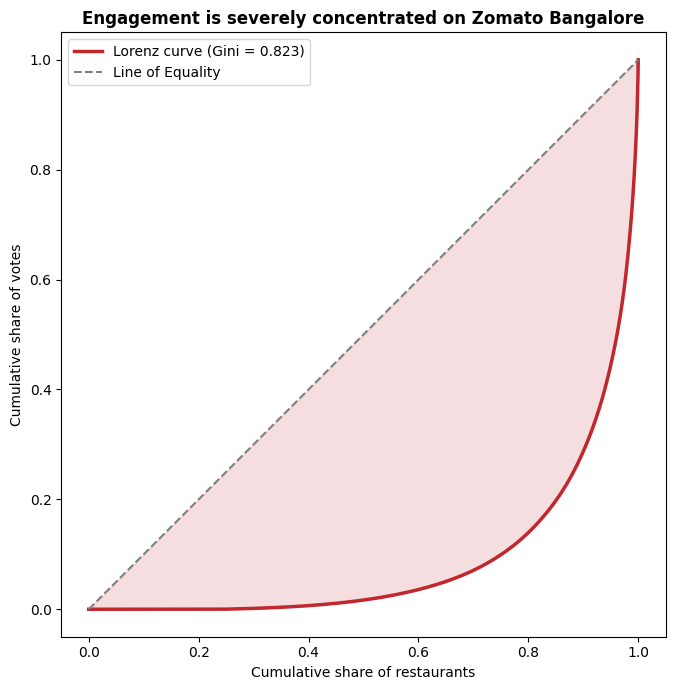

In [7]:
v = np.sort(votes)
cum = np.insert(np.cumsum(v) / v.sum(), 0, 0)
pct = np.linspace(0, 1, len(cum))

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(pct, cum, lw=2.5, color='#C1272D', label=f'Lorenz curve (Gini = {g:.3f})')
ax.plot([0, 1], [0, 1], ls='--', color='gray', lw=1.5, label='Line of Equality')
ax.fill_between(pct, cum, pct, alpha=0.15, color='#C1272D')
ax.set_xlabel('Cumulative share of restaurants')
ax.set_ylabel('Cumulative share of votes')
ax.set_title('Engagement is severely concentrated on Zomato Bangalore', fontweight='bold')
ax.legend(loc='upper left'); ax.set_aspect('equal')
plt.savefig("lorenz_curve.png", dpi=300, bbox_inches="tight")
plt.tight_layout()

## Finding - Engagement on Zomato Bangalore is severely concentrated: the Gini coefficient of votes is 0.823, far above our pre-registered 0.60 threshold, with the top 10% of restaurants capturing 71% of all votes. This exceeds the income inequality of virtually every national economy — attention here is more unequally distributed than wealth.

## What it means for the platform - Because discovery surfaces are ranked on popularity, this concentration is self-reinforcing: a small set of already-visible restaurants absorbs the overwhelming majority of engagement, while the long tail — including thousands of restaurants with near-zero votes — remains structurally invisible to users. This is the core discovery problem the platform must solve.

## What it raises - If popularity is this concentrated, the decisive question is what the popularity signal actually rewards — genuine quality, or mere structural exposure such as listing breadth and tenure. H2 tests exactly this.

# Hypothesis 2: What the Popularity Signal Rewards

## 1. Claim: Restaurant engagement (votes) is driven more by structural exposure (listing breadth) than by quality (rating). If true, the platform's popularity signal rewards incumbency over merit.
## 2. Operationalization: Multiple linear regression of log1p(votes) on rate_filled, rate_missing, listing_breadth, cost, online_order, and book_table, fit on the restaurants table. Outcome is log-transformed because votes is severely right-skewed (Gini 0.82) with zeros; log1p handles both.
## 3. Missing-data handling: rate is missing-not-at-random (absent for cold-start restaurants), so those ~19% are retained via a missing-indicator (rate_missing) plus median-fill, rather than dropped. The rate_missing coefficient itself estimates the cold-start effect on votes.
## 4. Decision rule: The stronger driver is judged by standardized (beta) coefficients, not raw coefficients or p-values — with ~12k rows every predictor will be "significant," so significance is uninformative; only relative effect size matters. If |β_listing_breadth| > |β_rate_filled|, exposure beats quality.
## 5. Assumption checks: VIF (multicollinearity), Breusch-Pagan (heteroscedasticity), residual inspection — reported before interpreting coefficients.
## 6. Prediction: listing_breadth will be the stronger standardized driver (exposure > quality). Note: if rate wins instead, this does not exonerate the platform — H1's concentration still stands; it would only mean the discovery problem operates through a different mechanism.
## 7. Frame: restaurants (restaurant grain). Joining listings would fan out popular restaurants across categories and inflate their weight.

In [8]:
df = restaurants.copy()

In [9]:
# outcome: lop1p handles the zeros (Gini 0.82 skew forces the transform)
df['log_votes'] = np.log1p(df['votes'])

In [10]:
# MNAR handling for rate: flag first, THEN fill - order matters.
df['rate_missing'] = df['rate'].isna().astype(int)
df['rate_filled'] = df['rate'].fillna(df['rate'].median())

In [11]:
# predictors for the model
features = ['rate_filled', 'rate_missing', 'listing_breadth', 'cost', 'online_order', 'book_table']
model_df = df[['log_votes'] + features].dropna()
print("rows entering model:", len(model_df), "of", len(df))

rows entering model: 12444 of 12499


In [12]:
print("rate missing sum:", df['rate_missing'].sum())

rate missing sum: 2992


In [13]:
import statsmodels.api as sm
X = sm.add_constant(model_df[features])
y = model_df['log_votes']
ols = sm.OLS(y, X).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:              log_votes   R-squared:                       0.788
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     7698.
Date:                Sun, 12 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:15:15   Log-Likelihood:                -18055.
No. Observations:               12444   AIC:                         3.612e+04
Df Residuals:                   12437   BIC:                         3.618e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -3.0060      0.097    -

## The feature engineered to retain the cold-start group is now dominating the model precisely because cold-start restaurants are defined by low engagement — the thing to be predicted.

### rate_missing was retained for row-preservation but proved to be a near-proxy for the low-engagement cold-start condition (it drove R² to 0.79, a leakage signature). For the breadth-vs-quality comparison, we refit on rated restaurants only, isolating the drivers among restaurants the platform can actually evaluate. The cold-start population is analyzed directly in H4

In [14]:
rated = model_df[model_df['rate_missing'] == 0].copy()
feats2 = ['rate_filled', 'listing_breadth', 'cost', 'online_order', 'book_table']
X2 = sm.add_constant(rated[feats2])
y2 = rated['log_votes']
ols2 = sm.OLS(y2, X2).fit()
print(ols2.summary())

                            OLS Regression Results                            
Dep. Variable:              log_votes   R-squared:                       0.465
Model:                            OLS   Adj. R-squared:                  0.465
Method:                 Least Squares   F-statistic:                     1647.
Date:                Sun, 12 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:15:15   Log-Likelihood:                -14930.
No. Observations:                9478   AIC:                         2.987e+04
Df Residuals:                    9472   BIC:                         2.991e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -3.0418      0.110    -

## Multicollinearity Flag - Cond. No. 6.56e+03

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
Xc = X2.drop(columns='const')
vif = pd.DataFrame({'feature': Xc.columns,
                    'VIF': [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])]})
print(vif)

           feature        VIF
0      rate_filled  10.223162
1  listing_breadth   8.050143
2             cost   4.323192
3     online_order   2.768505
4       book_table   1.723612


In [16]:
from statsmodels.stats.diagnostic import het_breuschpagan
bp = het_breuschpagan(ols2.resid, ols2.model.exog)
print(f"Breusch-Pagan p-value: {bp[1]:.4f}")

Breusch-Pagan p-value: 0.0000


## Fixing scale, collinearity and condition number

In [17]:
from sklearn.preprocessing import StandardScaler
feats2 = ['rate_filled', 'listing_breadth', 'cost', 'online_order', 'book_table']
Xz = pd.DataFrame(StandardScaler().fit_transform(rated[feats2]),
                  columns=feats2, index=rated.index)
Xz = sm.add_constant(Xz)
ols_std = sm.OLS(rated['log_votes'], Xz).fit(cov_type='HC3')
# print(ols_std.summary())

#confirming the VIF collapse
vif2 = pd.DataFrame({'feature': feats2,
                     'VIF': [variance_inflation_factor(Xz.drop(columns='const').values, i) for i in range(len(feats2))]})
print(vif2)

           feature       VIF
0      rate_filled  1.213618
1  listing_breadth  1.154518
2             cost  1.667605
3     online_order  1.048729
4       book_table  1.713484


In [18]:
print(ols_std.summary())

                            OLS Regression Results                            
Dep. Variable:              log_votes   R-squared:                       0.465
Model:                            OLS   Adj. R-squared:                  0.465
Method:                 Least Squares   F-statistic:                     1445.
Date:                Sun, 12 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:15:17   Log-Likelihood:                -14930.
No. Observations:                9478   AIC:                         2.987e+04
Df Residuals:                    9472   BIC:                         2.991e+04
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.1184      0.012    3

In [19]:
betas = ols_std.params.drop('const').abs().sort_values(ascending=False)

In [20]:
print(betas)

rate_filled        0.700318
cost               0.325847
online_order       0.283431
book_table         0.205299
listing_breadth    0.163353
dtype: float64


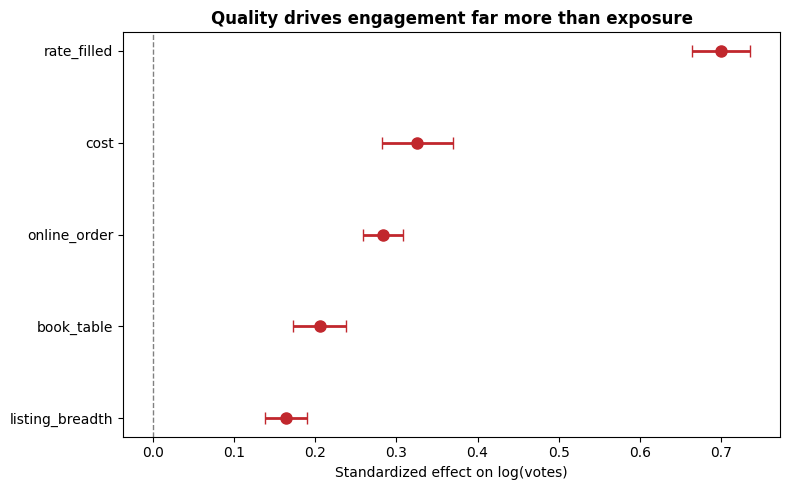

In [21]:
import matplotlib.pyplot as plt

b = ols_std.params.drop('const')
ci = ols_std.conf_int().drop('const')
order = b.abs().sort_values().index          # weakest→strongest, so strongest lands on top
b, ci = b[order], ci.loc[order]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(b.values, range(len(b)),
            xerr=[(b-ci[0]).values, (ci[1]-b).values],
            fmt='o', color='#C1272D', capsize=4, lw=2, markersize=8)
ax.axvline(0, ls='--', color='gray', lw=1)
ax.set_yticks(range(len(b))); ax.set_yticklabels(b.index)
ax.set_xlabel('Standardized effect on log(votes)')
ax.set_title('Quality drives engagement far more than exposure', fontweight='bold')
plt.tight_layout()

## Finding. Contrary to our pre-registered prediction that exposure would dominate, quality is by far the strongest driver of engagement. Standardized on log-votes: rate (β=0.70) exceeds listing breadth (β=0.16) by more than 4×, with cost (0.33), online-order (0.28), and booking (0.21) in between. Exposure — the incumbency hypothesis — is the weakest driver of all. The model explains 46% of variance (HC3-robust), and the ranking is unchanged by breadth's known scrape contamination, which if anything biases it upward.

## What it means. The concentration H1 exposed is not an artifact of the platform rewarding incumbency or visibility — votes track genuine quality. The pathology is subtler and more actionable: engagement accrues to already-discovered high-quality restaurants, while good-but-unrated restaurants have no votes to surface them. This is a cold-start trap — quality is necessary but insufficient without the initial exposure that generates a first wave of votes.

## What it raises. If quality earns engagement but new restaurants can't demonstrate quality without first being seen, the critical population is the one with no signal at all — the 2,992 unrated cold-start restaurants. H4 quantifies and locates them.

## Hypothesis 3: Quality vs. Popularity Coupling
## 1. Claim: A restaurant's quality (rating) and its popularity (votes) are only loosely coupled. If the correlation is weak-to-moderate, then ranking discovery surfaces on popularity systematically surfaces popular-but-average restaurants and buries good-but-unknown ones.
## 2. Operationalization: Spearman's rank correlation (ρ) between rate and votes, on rated restaurants only.
## 3. Method justification: Spearman, not Pearson — Pearson assumes a linear relationship and is distorted by the severe right-skew of votes (Gini 0.82) and its outliers; Spearman operates on ranks and is robust to both. Rated-only, using real rate (not rate_filled), because median-filled values would pile up ties at the center and distort the rank structure.
## 4. Interpretation bands (pre-registered): |ρ| < 0.3 weak (popularity is a poor quality proxy — strong case for re-ranking); 0.3–0.5 moderate (partial proxy, meaningful discovery leakage); > 0.5 strong (popularity mostly tracks quality).
## 5. Prediction: ρ in the 0.3–0.4 range (weak-to-moderate) — votes are contaminated by non-quality signal (tenure, exposure, cost), so they can only loosely track rating. Note: a higher ρ would not exonerate the platform; it would relocate the discovery problem to the cold-start zero-vote tail (H4), which has no rank at all.
## 6. Frame: restaurants (rated subset, ~9,478). Correlating at listing grain would let popular restaurants contribute multiple times and inflate ρ. 

In [22]:
from scipy.stats import spearmanr

rated_real = restaurants.dropna(subset=['rate', 'votes'])
rho, p = spearmanr(rated_real['rate'], rated_real['votes'])
print(f"Spearman rho: {rho:.3f} (p={p:.2e}, n={len(rated_real):,})")

Spearman rho: 0.637 (p=0.00e+00, n=9,507)


## Finding. Contrary to our prediction of weak-to-moderate coupling, quality and popularity are strongly rank-correlated (Spearman ρ = 0.637, n≈9,500). Quality explains ~40% of the rank variance in votes — substantial, but leaving ~60% driven by non-quality factors.
## What it means. Popularity is a decent but leaky proxy for quality. Ranking discovery on votes surfaces good restaurants reasonably well among the rated population — so the discovery failure is not primarily mis-ranking. The leak (~60% of vote-variance unexplained by quality) is where good-but-under-exposed restaurants slip, and the cold-start tail sits entirely outside this relationship, having no votes to correlate.
## What it raises. This concentrates the entire discovery problem onto the population with no engagement signal at all — the unrated, near-zero-vote cold-start restaurants. H4 quantifies and locates them.

            median  count
rate_bin                 
(0.0, 2.5]   138.5     74
(2.5, 3.0]    45.0    789
(3.0, 3.5]    11.0   3002
(3.5, 4.0]    70.0   4106
(4.0, 4.5]   413.0   1431
(4.5, 5.0]  1822.0    105


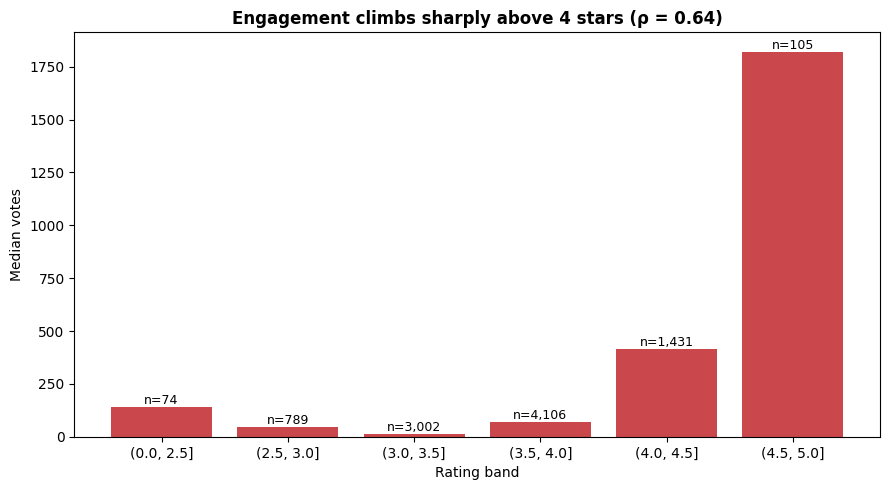

In [23]:
import matplotlib.pyplot as plt
d = rated_real.copy()
d['rate_bin'] = pd.cut(d['rate'], bins=[0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])   # coarse low end, fine where data lives
g = d.groupby('rate_bin', observed=True)['votes'].agg(['median', 'count'])
print(g)                                              # READ the counts before trusting any bar

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar([str(i) for i in g.index], g['median'].values, color='#C1272D', alpha=0.85)
# annotate each bar with its n, so sparse bars are visibly untrustworthy
for bar, n in zip(bars, g['count'].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'n={n:,}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Rating band'); ax.set_ylabel('Median votes')
ax.set_title(f'Engagement climbs sharply above 4 stars (ρ = {rho:.2f})', fontweight='bold')
plt.tight_layout()

## Finding. Quality and popularity are strongly rank-correlated (ρ = 0.64), but the relationship is sharply non-linear and threshold-gated, not linear. Median votes stay near the floor (11–70) across the 3.0–4.0 band where ~75% of rated restaurants sit, then jump to 413 at 4.0–4.5 and 1,822 above 4.5 — a 165× gap between the top tier and the crowded middle. (The uptick below 2.5 rests on 74 restaurants and is not interpreted.)
## What it means. Popularity is a leaky, threshold-gated proxy for quality. Because most inventory clusters in the mid-quality band where engagement barely differentiates, ranking-by-votes gives the large majority almost no discovery signal from rating — only the elite few above 4.5 are meaningfully surfaced.
## What it raises. If even rated mid-quality restaurants are near-invisible, the restaurants with no rating at all — the cold-start population — are entirely outside the discovery system. H4 quantifies and locates them.

## Hypothesis 4: The Cold-Start Gap
## 1. Claim: A substantial share of restaurants are invisible to the platform's discovery system — they have neither a quality signal (rating) nor an engagement signal (votes) for the recommender to act on. Furthermore, this invisibility is not random: cold-start restaurants concentrate systematically in specific neighborhoods, making the problem targetable.
## 2. Definition (load-bearing): A restaurant is cold-start if it has no usable rating (rate is null / was NEW) AND near-zero engagement (votes ≤ 5). This captures restaurants the platform can neither evaluate for quality nor rank on demand — the purest "invisible to the system" case. Restaurants missing only one signal (rated-but-unvoted, or unrated-but-voted) are tracked separately via a signal-overlap cross-tab, not folded into the core count.
## 3. Operationalization — two parts:
## Sizing (descriptive): count cold-start restaurants as a raw number and share of all 12,499; cross-tabulate the three invisibility signals (rate_missing, is_new, votes ≤ 5) to show how they overlap.
## Locating (inferential): chi-square test of independence between cold-start status and location, with Cramér's V as the effect size — because at n=12,499 the chi-square p-value is uninformative; only the strength of association matters.
## 4. Interpretation bands (pre-registered, Cramér's V): < 0.1 negligible (invisibility is diffuse — platform-wide fix needed); 0.1–0.3 moderate (some neighborhood clustering — partially targetable); > 0.3 strong (heavily concentrated in specific zones — precisely targetable).
## 5. Predictions: (a) cold-start share ≈ 19% of restaurants; (b) Cramér's V will be 0.32 — cold-start restaurants will cluster in newer/peripheral neighborhoods (Whitefield, Bellandur, Electronic City) rather than established hubs, because undiscovered restaurants concentrate in expanding areas. Note: even a negligible Cramér's V does not dissolve the finding — it would only mean the fix must be platform-wide rather than geographically targeted.
## 6. Frame: restaurants (restaurant grain, all 12,499 — cold-start is defined including the unrated, so unlike H2/H3 we do not restrict to rated restaurants; the whole point is the unrated population).

In [24]:
r = restaurants.copy()
r['low_votes'] = (r['votes'] <= 5).astype(int)
r['unrated'] = r['rate'].isna().astype(int)
r['cold_start'] = ((r['unrated'] == 1) & (r['low_votes'] == 1)).astype(int)

n = len(r)
print(f"Cold-Start: {r['cold_start'].sum():,} of {n:,} = {r['cold_start'].mean():.1%}")

# signal overlap - how do 'unrated' and 'low-votes' relate?
print(pd.crosstab(r['unrated'], r['low_votes'],
                  rownames=['unrated'], colnames=['low_votes'], margins=True))

Cold-Start: 2,992 of 12,499 = 23.9%
low_votes     0     1    All
unrated                     
0          8941   566   9507
1             0  2992   2992
All        8941  3558  12499


## Sizing finding. 2,992 restaurants — 23.9% of Bangalore's inventory — are cold-start: they carry no rating for the platform to evaluate. Notably, the two invisibility signals are perfectly nested: every unrated restaurant also has ≤5 votes (the "unrated & high-votes" cell is exactly zero). Rating and votes are generated by the same underlying process — user engagement — so "unrated" and "unengaged" are not two independent problems but two measurements of one: a restaurant the platform simply hasn't surfaced. A further 566 restaurants are rated but barely voted, bringing the total low-engagement population to 3,558; the 2,992 cold-start cases are the harder problem, because the recommender has no signal whatsoever to act on.
## (Prediction check: forecast was 19%; actual 23.9%. The gap reflects a wrong assumption — that unrated and low-vote would only partially overlap. The data shows they nest perfectly, so cold-start equals the full unrated set rather than a subset of it.)

In [25]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(r['location'], r['cold_start'])
chi2, p, dof, _ = chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (len(r) * (min(ct.shape) - 1)))
print(f"Chi-square: {chi2:.1f} | p={p:.2e} | Cramér's V = {cramers_v:.3f}")

# and SEE it: top/bottom locations by cold-start rate (min 50 restaurants, to avoid small-n noise)
loc = r.groupby('location').agg(cold_rate=('cold_start', 'mean'), n=('cold_start', 'size'))
loc = loc[loc['n'] >= 50].sort_values('cold_rate', ascending=False)
print("\nHighest cold-start neighborhoods:\n", loc.head(8))
print("\nLowest cold-start neighborhoods:\n", loc.tail(8))

Chi-square: 478.2 | p=1.62e-53 | Cramér's V = 0.196

Highest cold-start neighborhoods:
                        cold_rate    n
location                             
Ejipura                 0.476923   65
Shivajinagar            0.442623   61
Bommanahalli            0.440000  100
Electronic City         0.372603  730
Basaveshwara Nagar      0.361905  105
Wilson Garden           0.340000   50
Shanti Nagar            0.337662   77
Koramangala 1st Block   0.315152  165

Lowest cold-start neighborhoods:
                        cold_rate    n
location                             
Koramangala 6th Block   0.112583  151
Residency Road          0.108434   83
Koramangala 7th Block   0.103448  145
Koramangala 5th Block   0.085821  268
Jeevan Bhima Nagar      0.080000   75
Yeshwantpur             0.072464   69
Lavelle Road            0.071429   56
Church Street           0.035088   57


## Finding. Nearly a quarter of Bangalore's restaurants (2,992; 23.9%) are cold-start — unrated and unengaged, the two signals perfectly nested. This invisibility is not random: it clusters by neighborhood at a moderate strength (Cramér's V = 0.196, well above chance). But — contrary to the prediction that new/peripheral zones would dominate — cold-start concentrates in under-served, lower-visibility neighborhoods (Ejipura 48%, Shivajinagar 44%, Bommanahalli 44%, Electronic City 37%), while established premium hubs are near-fully discovered (Church Street 3.5%, Lavelle Road, Koramangala). Discovery tracks affluence and establishment, not newness.
## What it means. The platform's discovery gap is real, large, and partially geographic. Because clustering is moderate rather than dominant, the invisible population can't be fixed by targeting a few zones alone — but the neighborhood signal is strong enough that a targeted discovery boost in the worst-served areas (led by Electronic City, given its scale of 730 restaurants) would recover a meaningful share of cold-start supply. The fix is both targeted and platform-wide.
## What it raises. If a quarter of supply is invisible and concentrated in specific under-served neighborhoods, the platform faces a supply question: are those same neighborhoods also under-supplied in certain cuisines — thin markets the platform should help fill? H5 maps supply gaps by neighborhood and cuisine.

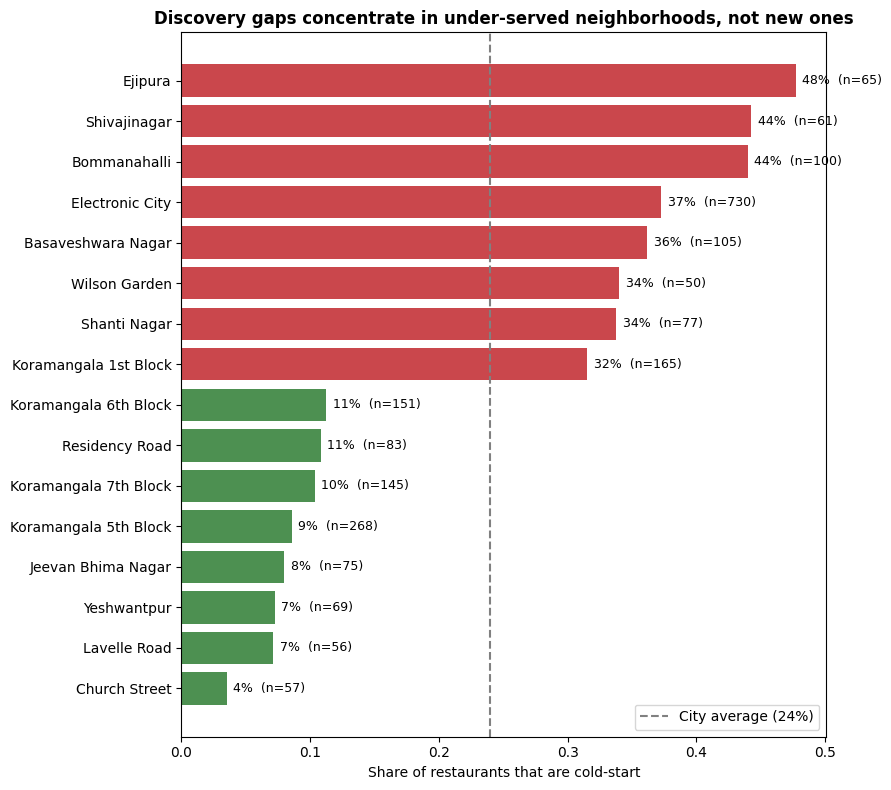

In [26]:
import matplotlib.pyplot as plt

combined = pd.concat([loc.head(8), loc.tail(8)]).sort_values('cold_rate')   # one clean gradient
city_avg = r['cold_start'].mean()
colors = ['#2E7D32' if v < city_avg else '#C1272D' for v in combined['cold_rate']]  # split at the average

fig, ax = plt.subplots(figsize=(9, 8))
bars = ax.barh(range(len(combined)), combined['cold_rate'].values, color=colors, alpha=0.85)
ax.set_yticks(range(len(combined))); ax.set_yticklabels(combined.index)
ax.axvline(city_avg, ls='--', color='gray', lw=1.5, label=f"City average ({city_avg:.0%})")
for i, (bar, n) in enumerate(zip(bars, combined['n'].values)):
    ax.text(bar.get_width() + 0.005, i, f"{bar.get_width():.0%}  (n={n})", va='center', fontsize=9)
ax.set_xlabel('Share of restaurants that are cold-start')
ax.set_title('Discovery gaps concentrate in under-served neighborhoods, not new ones', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()

## Finding. Nearly a quarter of Bangalore's restaurants (2,992; 23.9%) are cold-start — unrated and unengaged, the two signals perfectly nested (no unrated restaurant has more than 5 votes). This invisibility clusters by neighborhood at moderate strength (Cramér's V = 0.196, χ² p ≪ 0.001). Contrary to the prediction that new/peripheral zones would dominate, cold-start concentrates in under-served, lower-visibility neighborhoods — Ejipura (48%), Shivajinagar (44%), Bommanahalli (44%), Electronic City (37%) — while established premium hubs are near-fully discovered (Church Street 4%, Lavelle Road 7%, the Koramangala blocks). Discovery tracks affluence and establishment, not newness — a 12× spread between the worst and best neighborhoods.
## What it means. The discovery gap is large, real, and partially geographic. Because clustering is moderate rather than dominant, no handful of zones fully explains it — the fix must be both targeted and platform-wide. But the geographic signal is strong enough to prioritize: ranking by absolute recoverable supply (rate × neighborhood size), Electronic City is the clear first target — its 37% cold-start rate spans 730 restaurants, ~270 invisible, the largest recoverable pool of any neighborhood. A targeted discovery boost there, followed by the other high-rate under-served zones, would recover meaningful supply that quality-based ranking currently cannot surface (because these restaurants have no quality signal to rank on).
## What it raises. If a quarter of supply is invisible and concentrated in under-served neighborhoods, the platform faces a complementary supply question: are those same neighborhoods also thin in certain cuisines — under-supplied markets the platform should help fill? H5 maps supply coverage across neighborhood and cuisine.

## Hypothesis 5: Supply Gaps
## 1. Claim: Bangalore's restaurant supply is unevenly matched to demand — there exist neighborhood × cuisine niches where demand is high but supply is thin. These under-supplied niches are the platform's recruitment targets. The gaps are expected to be location-driven (whole neighborhoods thin across cuisines) more than cuisine-driven, and to diverge meaningfully from the H4 cold-start neighborhoods — i.e., under-supplied areas are not the same as undiscovered ones.
## 2. Definition (load-bearing): A supply gap is a (location, cuisine) niche with thin supply and high demand-per-restaurant, measured as median votes per restaurant within the niche — high median votes across few restaurants indicates the existing supply is absorbing outsized demand, signalling appetite the market isn't serving. Niches are floored at a minimum restaurant count (MIN_N) to exclude single-outlier noise; median (not summed) votes is used so a multi-cuisine restaurant's engagement is never double-counted across niches.
## 3. Operationalization — two layers:

## Coverage matrix: restaurant count per (location, cuisine) — where supply is thin or absent.
## Demand-intensity matrix: median votes-per-restaurant per niche — where thin supply meets high demand. A gap is the intersection: low count + high median votes.

## 4. Predictions: (a) gaps are predominantly location-driven; (b) supply-gap neighborhoods diverge from H4's cold-start zones (under-supplied ≠ undiscovered). Note: strong overlap instead would collapse H4 and H5 into a single "under-served zones" super-finding — the divergence bet is the claim that these are distinct problems needing distinct fixes.
## 5. Frame: restaurant_cuisines (the many-to-many bridge) joined to restaurants for location and votes. Grain caveat: after the join, a restaurant with k cuisines appears in k niche-rows; votes are aggregated by median within niche, never summed across the exploded frame, to avoid re-inflating engagement.

In [27]:
# joining bridge (name, address, cuisine) -> restaurants(location, votes)
restaurants['cold_start'] = (restaurants['rate'].isna() & (restaurants['votes'] <= 5)).astype(int)
rc = restaurants_cuisines.merge(restaurants[['name', 'address', 'location', 'votes', 'cold_start']],
                               on = ['name', 'address'], how='left')
print("bridge rows:", len(restaurants_cuisines), "| joined rows:", len(rc))
print("null location after join:", rc['location'].isna().sum())

bridge rows: 29363 | joined rows: 29363
null location after join: 0


In [28]:
# demand-intensity per niche: median votes per restaurant, with the n floor
niche = (rc.groupby(['location', 'cuisine'])
         .agg(n_restaurant=('name', 'size'),
              median_votes=('votes', 'median'))
         .reset_index())

MIN_N = 5  # floor: ignore niches too thin to trust.
niche_f = niche[niche['n_restaurant'] >= MIN_N]
print(f"niches total: {len(niche)} | above floor (n>={MIN_N}): {len(niche_f)}")

niches total: 2965 | above floor (n>=5): 1131


## Niches below n=5 are excluded not because thin supply disqualifies a gap, but because demand-per-restaurant cannot be reliably estimated from 1-4 observations; the truly empty niches (zero restaurants) are addressed separately as absolute coverage gaps.

In [29]:
niche['n_restaurant'].describe()

count    2965.000000
mean        9.903204
std        24.899306
min         1.000000
25%         1.000000
50%         3.000000
75%         8.000000
max       425.000000
Name: n_restaurant, dtype: float64

In [30]:
# gap-score: high demand per restaurant , among reliably measured niches
gaps = niche_f.sort_values('median_votes', ascending=False)
print("Top demand-intensity niches (potential supply gaps):")
print(gaps.head(15).to_string(index=False))

Top demand-intensity niches (potential supply gaps):
             location       cuisine  n_restaurant  median_votes
Koramangala 5th Block   Finger Food             9        2380.0
         Marathahalli Mediterranean             7        1914.0
Koramangala 5th Block      American            12        1906.5
         Lavelle Road         Salad             7        1867.0
Koramangala 5th Block         Steak             5        1799.0
        Church Street      American             7        1769.0
          Indiranagar           BBQ             7        1699.0
Koramangala 5th Block      European             8        1695.0
Koramangala 5th Block         Asian            15        1592.0
        Sarjapur Road   Finger Food             5        1476.0
        Church Street       Italian             5        1359.0
           Whitefield      European             9        1140.0
          Indiranagar      European            12        1121.0
          Indiranagar Mediterranean             5  

## Finding. Supply gaps are location-driven and diverge sharply from H4's discovery gaps. High demand-per-restaurant concentrates in a few premium neighborhoods — Koramangala 5th Block (5 of the top 15 niches), Indiranagar, Church Street, Lavelle Road — across niche cuisines (Finger Food, Mediterranean, Steak, European). These are the opposite of the cold-start peripheries: Church Street had the lowest cold-start rate (4%). The typical neighborhood-cuisine niche is thin (median 3 restaurants).
## What it means. The city has two distinct under-service problems in two different areas. In the poor peripheries (H4), restaurants exist but are undiscovered. In the affluent centers (H5), specific niche cuisines are under-supplied relative to intense local demand. (Caveat: premium-area intensity may partly reflect those neighborhoods' high baseline engagement; a neighborhood-normalized measure would sharpen this.)
## What it raises. The two problems imply two different platform levers — discovery surfacing in the peripheries, targeted cuisine recruitment in the centers. Both connect to how restaurants monetize on the platform, which H6 examines via online-ordering adoption.

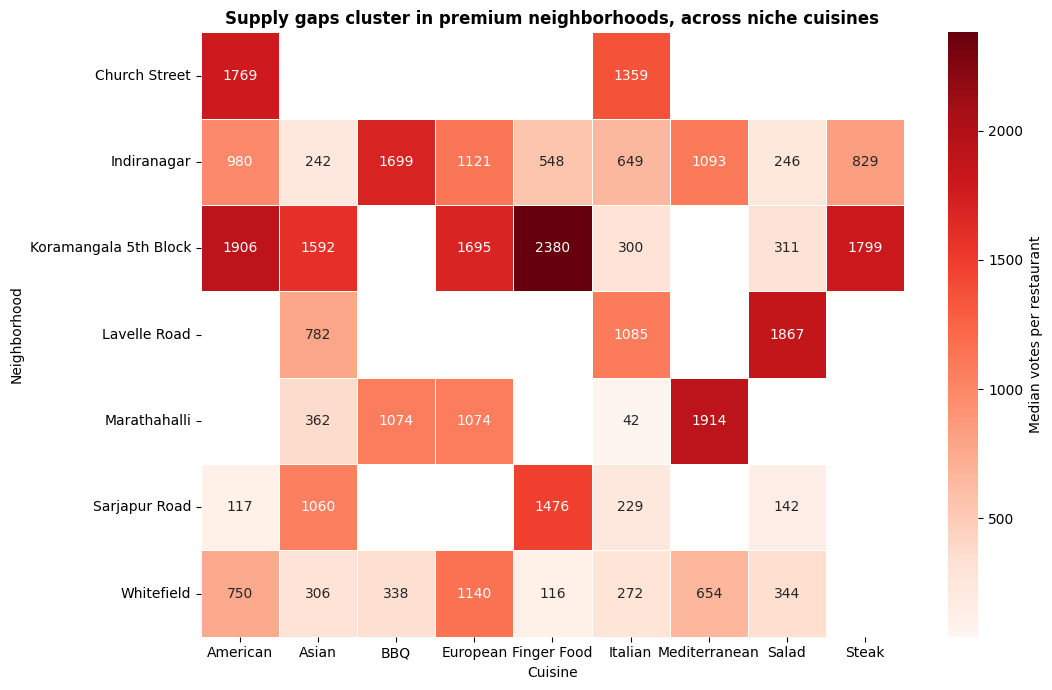

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# focus on the neighborhoods and cuisines that dominate the gap list
top_locs = gaps.head(15)['location'].unique()
top_cuis = gaps.head(15)['cuisine'].unique()

# pivot demand-intensity into a matrix, restricted to those, and keep the n≥5 floor
sub = niche_f[niche_f['location'].isin(top_locs) & niche_f['cuisine'].isin(top_cuis)]
pivot = sub.pivot(index='location', columns='cuisine', values='median_votes')

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Reds', linewidths=0.5,
            cbar_kws={'label': 'Median votes per restaurant'}, ax=ax)
ax.set_title('Supply gaps cluster in premium neighborhoods, across niche cuisines',
             fontweight='bold')
ax.set_xlabel('Cuisine'); ax.set_ylabel('Neighborhood')
plt.tight_layout()

## Church Street's near-empty row) represent absolute supply gaps — cuisines with too little presence to register — and are the sharpest recruitment targets.

In [32]:
plt.savefig("supply_gaps_heatmap.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## Hypothesis 6: Monetization Adoption Gaps
## 1. Claim: Online-ordering adoption — the platform's core delivery/commission lever — is unevenly distributed across restaurant segments. Low-adoption segments are the platform's onboarding growth targets. Adoption is expected to be structured most strongly by [your predicted dimension].
## 2. Operationalization: Chi-square test of independence between online_order (0/1) and each segmenting variable — location, cost_tier, rest_type — with Cramér's V as the effect size, since at n=12,499 the p-value is uninformative and only association strength matters. The dimension with the highest Cramér's V identifies the primary axis of adoption inequality.
## 3. Population/frame: All 12,499 restaurants (restaurants table). Online-order status is a business decision every restaurant has made, independent of engagement, so cold-start restaurants are included — unlike H2/H3's rated-only restriction.
## 4. Interpretation bands (pre-registered, Cramér's V): <0.1 negligible (uniform adoption); 0.1–0.3 moderate (partially targetable); >0.3 strong (clearly segmented onboarding targets).
## 5. Predictions: (a) rest_type is the primary dimension structuring adoption — cheap-and-fast formats adopt online-ordering most, fine-dining least, to preserve the in-person experience; cost_tier shows similar but slightly weaker structure. (b) Within rest_type, Quick Bites / budget formats adopt most. (c) Low adoption concentrates in the H4 cold-start peripheries (Story B) — implying adoption is gated by geography/infrastructure, not format alone. Note: predictions (a) and (c) are in tension — if adoption were purely format-driven and peripheries are cheap-format, they should adopt more, not less. The relative Cramér's V of rest_type vs location adjudicates: format-driven (a wins, low-adoption in premium centers) vs geography-driven (c wins, low-adoption in peripheries).
## 6. Requirement: cost_tier must be engineered first (bin cost into Budget/Mid/Premium/Luxury) — note this is a new feature; define the cut points and justify them.

In [35]:
# fixed Bangalore-dining thresholds; labels interpretable, groups unequal but adequately sized.
bins = [0, 300, 600, 1200, 10000]
labels = ['Budget (<₹300)', 'Mid (₹300–600)', 'Premium (₹600–1200)', 'Luxury (>₹1200)']
restaurants['cost_tier'] = pd.cut(restaurants['cost'], bins=bins, labels=labels)
print(restaurants.groupby('cost_tier', observed=True)['cost'].agg(['min','max','count']))

                        min     max  count
cost_tier                                 
Budget (<₹300)         40.0   300.0   5135
Mid (₹300–600)        325.0   600.0   4879
Premium (₹600–1200)   625.0  1200.0   1854
Luxury (>₹1200)      1250.0  6000.0    576


## fixed thresholds yield unequal but adequately-sized tiers (min n=576), preserving both label honesty and chi-square validity.

## four in five restaurants serve a meal for two under ₹600".

In [37]:
# rest_type wasn't carried into the sealed table; pull it from raw, take primary type
raw = pd.read_csv('zomato.csv', usecols=['name','address','rest_type'])
raw['rest_type'] = raw['rest_type'].astype(str).str.split(',').str[0].str.strip()
primary = raw.dropna(subset=['rest_type']).drop_duplicates(subset=['name','address'])
restaurants = restaurants.merge(primary[['name','address','rest_type']],
                                on=['name','address'], how='left')
print(restaurants['rest_type'].value_counts().head(10))
print("null rest_type:", restaurants['rest_type'].isna().sum())

rest_type
Quick Bites       5111
Casual Dining     2459
Delivery           927
Takeaway           786
Dessert Parlor     649
Cafe               635
Bakery             448
Beverage Shop      378
Food Court         221
Sweet Shop         173
Name: count, dtype: int64
null rest_type: 63


In [38]:
from scipy.stats import  chi2_contingency
import numpy as np

def cramers_v(cat, target='online_order', data=restaurants):
    d = data.dropna(subset=[cat])
    ct = pd.crosstab(d[cat], d[target])
    chi2, p, _, _ = chi2_contingency(ct)
    return np.sqrt(chi2 / (len(d) * (min(ct.shape) - 1))), p, len(d)

print("What structures online-order adoption:")

for dim in ['rest_type', 'cost_tier', 'location']:
    v, p, n = cramers_v(dim)
    print(f"  {dim:11s} Cramer's V = {v:.3f} (n={n:,})")

for dim in ['rest_type', 'cost_tier']:
    print(f"\n{dim} - adoption rate (well populated segments):")
    t = restaurants.groupby(dim, observed=True)['online_order'].agg(['mean', 'size'])
    print(t[t['size'] >= 50].sort_values('mean', ascending=False))

What structures online-order adoption:
  rest_type   Cramer's V = 0.189 (n=12,436)
  cost_tier   Cramer's V = 0.183 (n=12,444)
  location    Cramer's V = 0.214 (n=12,490)

rest_type - adoption rate (well populated segments):
                    mean  size
rest_type                     
Beverage Shop   0.701058   378
Kiosk           0.619048    63
Delivery        0.604099   927
Casual Dining   0.600651  2459
Takeaway        0.594148   786
Dessert Parlor  0.583975   649
Cafe            0.559055   635
Quick Bites     0.514576  5111
Food Court      0.493213   221
Sweet Shop      0.479769   173
Bakery          0.430804   448
Pub             0.290323    93
Mess            0.246753    77
Bar             0.183544   158
Lounge          0.106667    75
Fine Dining     0.043478    92

cost_tier - adoption rate (well populated segments):
                         mean  size
cost_tier                          
Mid (₹300–600)       0.622054  4879
Premium (₹600–1200)  0.603020  1854
Budget (<₹300)     

## Finding. Online-order adoption is moderately and roughly-equally structured by format, price tier, and location (Cramér's V 0.19, 0.18, 0.21 — no dominant lever). The direction is clear and business-model-driven: experience-formats reject delivery (Fine Dining 4%, Lounge 11%, Bar 18%, Pub 29%), while delivery-compatible formats adopt at 50-70%. By price, adoption is an inverted-U — Mid-tier highest (62%), falling to both Budget (46%) and Luxury (30%). Contrary to the "cheapest adopts most" prediction, the very cheapest under-adopt (likely margin/capacity constraints), and adoption peaks in the margin-healthy middle.
## What it means. Delivery adoption follows a business-model logic, not a simple cheap/expensive split: it suits margin-healthy, non-experience-dependent restaurants. The platform's monetization headroom is therefore not one clean segment — it spans three partly-overlapping gaps: experience-formats (structurally hard to convert), the sub-₹300 budget tier (needs onboarding/margin support), and lower-adoption neighborhoods (delivery-infrastructure). No single onboarding campaign captures it.
## What it raises. The clearest revenue opportunity is the Budget tier's under-adoption — 5,135 restaurants, the largest segment, at only 46% — where onboarding friction (not experience-protection) is the likely barrier, making it addressable in a way Fine Dining is not.
## (Prediction reconciliation: rest_type did not dominate as predicted — all three dimensions were comparable, and location edged highest. The "experience formats reject delivery" mechanism was confirmed, but the "cheapest adopts most" direction was wrong — adoption peaks mid-tier in an inverted-U.)

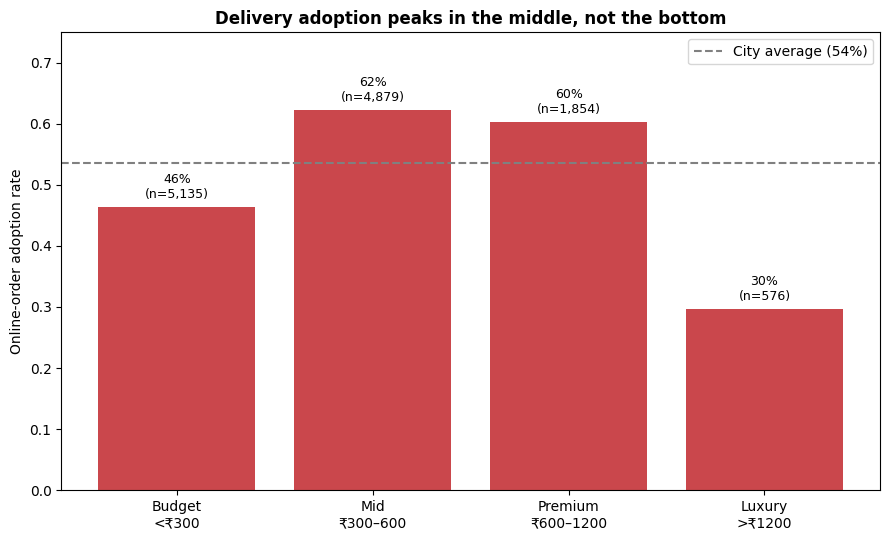

In [39]:
import matplotlib.pyplot as plt

order = ['Budget (<₹300)', 'Mid (₹300–600)', 'Premium (₹600–1200)', 'Luxury (>₹1200)']
adopt = restaurants.groupby('cost_tier', observed=True)['online_order'].agg(['mean','size']).reindex(order)

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(range(len(order)), adopt['mean'].values, color='#C1272D', alpha=0.85)
ax.axhline(restaurants['online_order'].mean(), ls='--', color='gray', lw=1.5,
           label=f"City average ({restaurants['online_order'].mean():.0%})")
ax.set_xticks(range(len(order)))
ax.set_xticklabels([o.split(' (')[0]+'\n'+o.split('(')[1][:-1] for o in order])
for bar, n, m in zip(bars, adopt['size'].values, adopt['mean'].values):
    ax.text(bar.get_x()+bar.get_width()/2, m+0.01, f"{m:.0%}\n(n={n:,})",
            ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, 0.75)
ax.set_ylabel('Online-order adoption rate')
ax.set_title('Delivery adoption peaks in the middle, not the bottom', fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()